In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import tqdm

In [2]:
with open('../results/fold1_labels.json', 'r') as f:   
    fold1 = json.load(f)
with open('../results/fold2_labels.json', 'r') as f:
    fold2 = json.load(f)
with open('../results/fold3_labels.json', 'r') as f:
    fold3 = json.load(f)
with open('../results/fold4_labels.json', 'r') as f:
    fold4 = json.load(f)

all_folds = fold1 + fold2 + fold3 + fold4
bprna_df = pd.DataFrame(all_folds)
bprna_df['RFID'] = bprna_df['reference_name'].str.split('_').str[0]

In [3]:
def get_sequence_and_db(bprna_id):
    with open(f'../data/unzipped/bpRNA_1m_90_STAFILES/{bprna_id}.st', 'r') as f:
        data = f.readlines()
    i = 0
    while data[i][0] == '#':
        i += 1
    seq = data[i].strip()
    db = data[i+1].strip()
    return seq, db

bprna_df['sequence'], bprna_df['db'] = zip(*bprna_df['bprna_id'].apply(get_sequence_and_db))
bprna_df['length'] = bprna_df['sequence'].apply(len)
rfam_data = pickle.load(open('../rfam/rfam_types_full.pkl', 'rb'))
rfam_df = pd.DataFrame(rfam_data.items(), columns=['RFID', 'type'])
rfam_df['meta_type'] = rfam_df['type'].str.split(';').str[0]
df = bprna_df.merge(rfam_df, on='RFID', how='left', indicator=True)


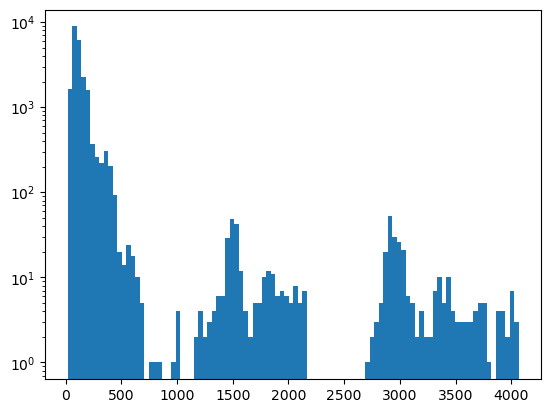

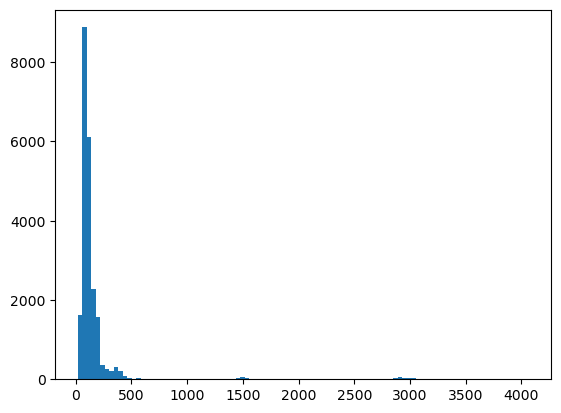

In [10]:
plt.hist(df['length'], bins=100)
plt.yscale('log')
plt.show()

plt.hist(df['length'], bins=100)
# plt.yscale('log')
plt.show()

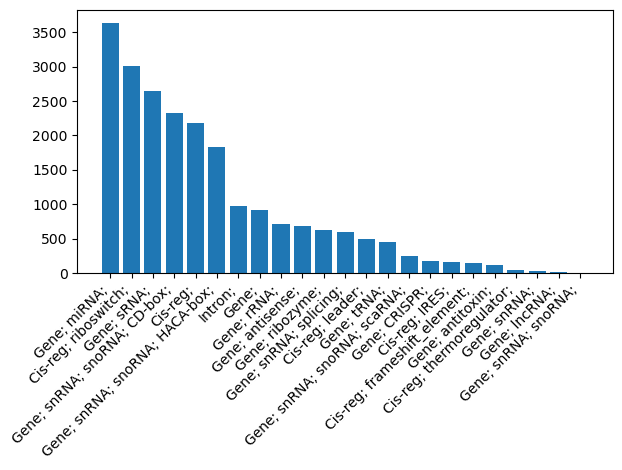

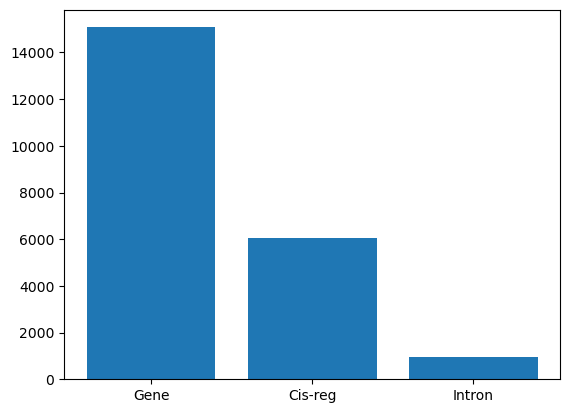

In [6]:
plt.bar(df['type'].value_counts().index, df['type'].value_counts().values)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

plt.bar(df['meta_type'].value_counts().index, df['meta_type'].value_counts().values)
plt.show()


In [ ]:
df.plot.hist(by = 'length', bins=100)

In [ ]:
df.plot.hist(x = 'length', bins=100)

In [29]:
df.sample(10)

,bprna_id,file_path,rna_type,reference_name,error,request_time_seconds,RFID,type,_merge
18797,bpRNA_RFAM_42837,data/unzipped/bpRNA_1m_90_bpseqFiles/bpRNA_RFA...,SNOR75,RF02539_AB013389.1_56436-56523,None,27.384180,RF02539,Gene; snRNA; snoRNA; CD-box;,both
12508,bpRNA_RFAM_30822,data/unzipped/bpRNA_1m_90_bpseqFiles/bpRNA_RFA...,Pseudomon-1,RF01719_CP000304.1_135860-135973,None,27.445146,RF01719,Gene; sRNA;,both
15799,bpRNA_RFAM_37227,data/unzipped/bpRNA_1m_90_bpseqFiles/bpRNA_RFA...,mir-969,RF01997_AAPU01009701.1_40639-40741,None,27.576874,RF01997,Gene; miRNA;,both
12397,bpRNA_RFAM_30495,data/unzipped/bpRNA_1m_90_bpseqFiles/bpRNA_RFA...,PhotoRC-II,RF01717_AACY020552257.1_3152-3247,None,27.697195,RF01717,Cis-reg;,both
5492,bpRNA_RFAM_19514,data/unzipped/bpRNA_1m_90_bpseqFiles/bpRNA_RFA...,mir-302,RF00668_AALT01320989.1_607-537,None,27.578478,RF00668,Gene; miRNA;,both
16860,bpRNA_RFAM_38840,data/unzipped/bpRNA_1m_90_bpseqFiles/bpRNA_RFA...,MIR2907,RF02027_AAAA02030917.1_28001-27937,None,27.326043,RF02027,Gene; miRNA;,both
10373,bpRNA_RFAM_2681,data/unzipped/bpRNA_1m_90_bpseqFiles/bpRNA_RFA...,RNaseP_bact_a,RF00010_CP000683.1_680077-680596,None,27.324843,RF00010,Gene; ribozyme;,both
3064,bpRNA_RFAM_15637,data/unzipped/bpRNA_1m_90_bpseqFiles/bpRNA_RFA...,Corona_FSE,RF00507_AF353511.1_12621-12699,None,27.267161,RF00507,Cis-reg; frameshift_element;,both
12817,bpRNA_RFAM_3146,data/unzipped/bpRNA_1m_90_bpseqFiles/bpRNA_RFA...,6S,RF00013_CP000644.1_2821324-2821506,None,27.438890,RF00013,Gene;,both
18096,bpRNA_RFAM_41663,data/unzipped/bpRNA_1m_90_bpseqFiles/bpRNA_RFA...,sau-59,RF02393_CP001781.1_1069087-1068960,None,27.545660,RF02393,Gene; sRNA;,both


In [ ]:
d